# ML Training Data Analysis

Demonstrates environment reproducibility:
1. Connect to the PostgreSQL container via service hostname
2. Fetch the pre-seeded training dataset
3. Generate a matplotlib scatter plot
4. Verify locked package versions with `pip list`

In [1]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import os

conn = psycopg2.connect(
    host=os.environ.get('POSTGRES_HOST', 'postgres'),
    dbname=os.environ.get('POSTGRES_DB', 'mldata'),
    user=os.environ.get('POSTGRES_USER', 'mluser'),
    password=os.environ.get('POSTGRES_PASSWORD', 'mlpassword')
)
print('Connected to PostgreSQL successfully!')

Connected to PostgreSQL successfully!


In [2]:
df = pd.read_sql('SELECT * FROM training_samples ORDER BY id', conn)
print(f'Loaded {len(df)} rows from training_samples')
df.head()

Loaded 15 rows from training_samples


/tmp/ipykernel_4492/305409281.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql('SELECT * FROM training_samples ORDER BY id', conn)


,id,sepal_length,sepal_width,petal_length,petal_width,species
0,1,5.1,3.5,1.4,0.2,setosa
1,2,4.9,3.0,1.4,0.2,setosa
2,3,4.7,3.2,1.3,0.2,setosa
3,4,4.6,3.1,1.5,0.2,setosa
4,5,5.0,3.6,1.4,0.2,setosa


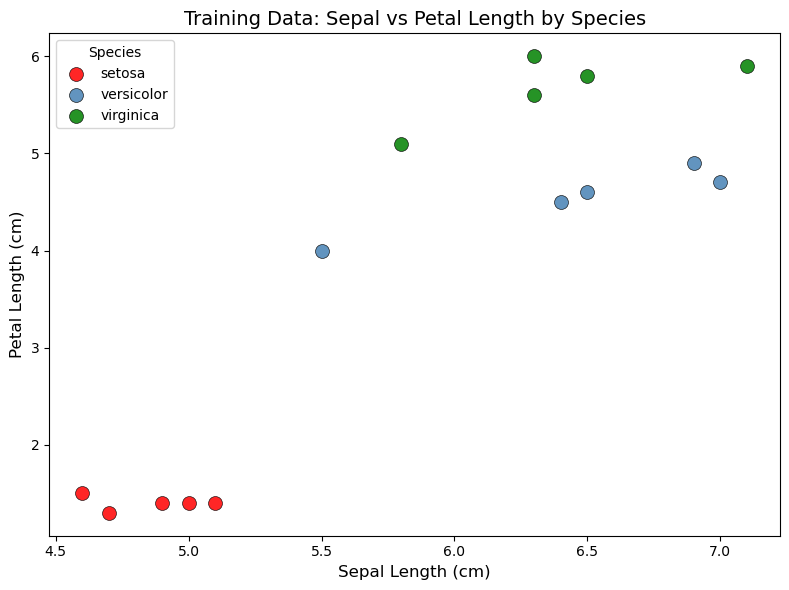

In [3]:
colors = {'setosa': 'red', 'versicolor': 'steelblue', 'virginica': 'green'}

fig, ax = plt.subplots(figsize=(8, 6))
for species, group in df.groupby('species'):
    ax.scatter(
        group['sepal_length'], group['petal_length'],
        label=species, color=colors[species], s=100, alpha=0.85, edgecolors='k', linewidths=0.5
    )

ax.set_xlabel('Sepal Length (cm)', fontsize=12)
ax.set_ylabel('Petal Length (cm)', fontsize=12)
ax.set_title('Training Data: Sepal vs Petal Length by Species', fontsize=14)
ax.legend(title='Species')
plt.tight_layout()
plt.show()

In [4]:
import subprocess
result = subprocess.run(['pip', 'list', '--format=columns'], capture_output=True, text=True)
print(result.stdout)

Package                       Version
----------------------------- ------------
alembic                       1.12.0
altair                        5.1.2
anyio                         4.0.0
argon2-cffi                   23.1.0
argon2-cffi-bindings          21.2.0
arrow                         1.3.0
asttokens                     2.4.0
async-generator               1.10
async-lru                     2.0.4
attrs                         23.1.0
Babel                         2.13.0
backcall                      0.2.0
backports.functools-lru-cache 1.6.5
beautifulsoup4                4.12.2
bleach                        6.1.0
blinker                       1.6.3
bokeh                         3.3.0
boltons                       23.0.0
Bottleneck                    1.3.7
Brotli                        1.1.0
cached-property               1.5.2
certifi                       2023.7.22
certipy                       0.1.3
cffi                          1.16.0
charset-normalizer            3.3.0
click   

In [5]:
conn.close()
print('Connection closed.')

Connection closed.
